### Churn Analysis and Retention Measures

### Libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, f1_score, precision_score
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
import shap

### EDA

In [2]:
df = pd.read_csv("Dataset.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

#### Relationship of Columns with Churn

In [4]:
#Function to calculate churn rate for a given column
def churn_rate(column):
    return pd.crosstab(
        df[column],
        df['Churn'],
        normalize='index'
    )['Yes'] * 100

In [5]:
#Function to plot churn rate for a given column
def plot_churn_rate(column):
    data = churn_rate(column).reset_index()
    sns.barplot(data=data, x=column, y='Yes')
    plt.title(f'{column} vs Churn Rate')
    plt.ylabel('Churn Rate (%)')
    plt.xlabel(column)
    plt.xticks(rotation=30)
    plt.show()

In [6]:
churn_rate('Contract')

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Yes, dtype: float64

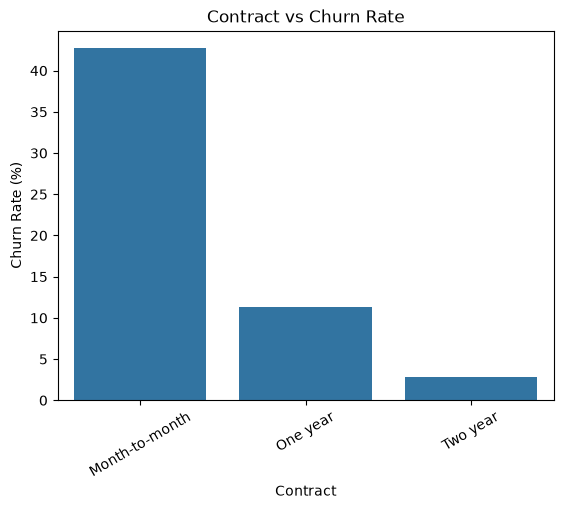

In [7]:
plot_churn_rate('Contract')

Customers on month-to-month contracts have the highest churn rate (42.71%), while customers on one-year contracts have much lower churn (11.27%). Customers on two-year contracts have the lowest churn rate (2.83%). Customers with longer-term contracts are much less likely to churn.

In [8]:
churn_rate('InternetService')

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Yes, dtype: float64

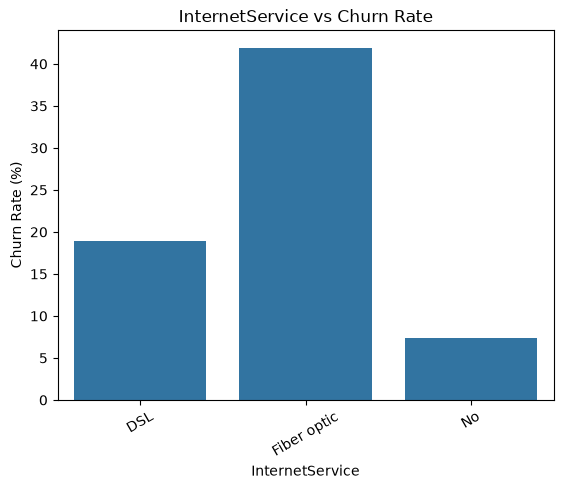

In [9]:
plot_churn_rate('InternetService')

Fiber optic customers have the highest churn rate at 41.89%, followed by DSL customers at 18.96%. Customers without internet service have the lowest churn rate at 7.40%.

In [10]:
churn_rate('PaymentMethod')

PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Yes, dtype: float64

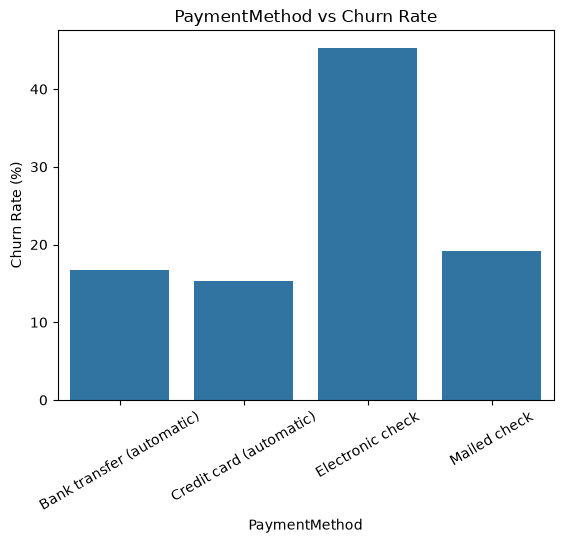

In [11]:
plot_churn_rate('PaymentMethod')

Customers using electronic checks have the highest churn rate at 45.29%, while customers using automatic credit card and bank transfer payments have much lower churn rates of 15.24% and 16.71%, respectively.

In [12]:
churn_rate('TechSupport')

TechSupport
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: Yes, dtype: float64

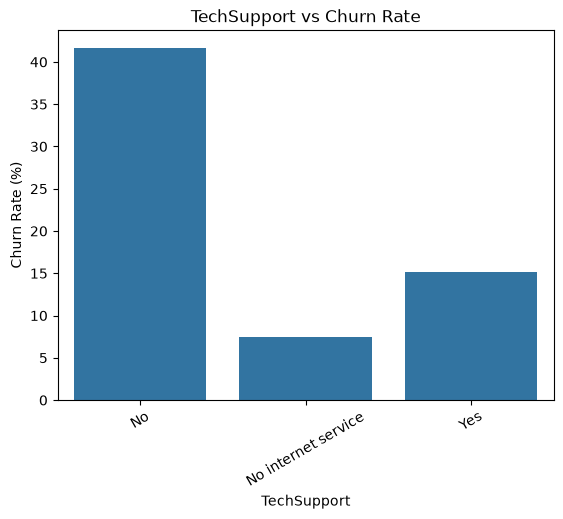

In [13]:
plot_churn_rate('TechSupport')

Customers without tech support have a much higher churn rate of 41.64%, while customers with tech support have a churn rate of 15.17%. Customers without internet service have the lowest churn rate at 7.40%.

In [14]:
churn_rate('OnlineSecurity')

OnlineSecurity
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: Yes, dtype: float64

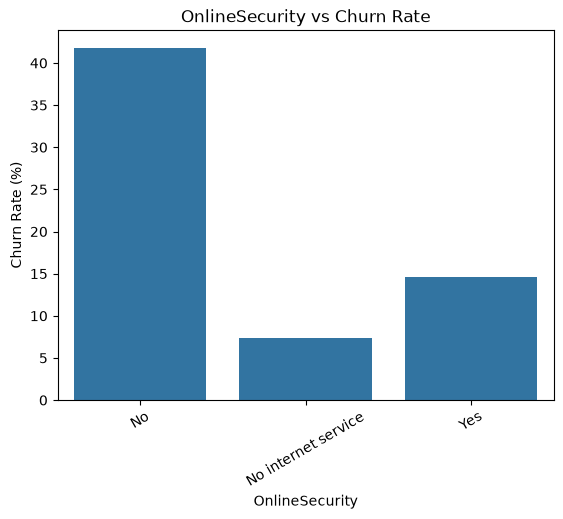

In [15]:
plot_churn_rate('OnlineSecurity')

Customers without online security have a much higher churn rate of 41.77%, while customers with online security have a churn rate of 14.61%. Customers without internet service have the lowest churn rate at 7.40%.

In [16]:
churn_rate('SeniorCitizen')

SeniorCitizen
0    23.606168
1    41.681261
Name: Yes, dtype: float64

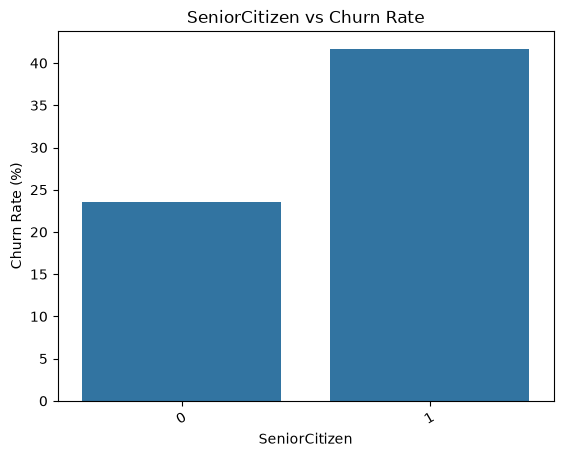

In [17]:
plot_churn_rate('SeniorCitizen')

Senior citizens have a higher churn rate of 41.68%, compared to 23.61% for non-senior citizens.

In [18]:
churn_rate('Partner')

Partner
No     32.957979
Yes    19.664903
Name: Yes, dtype: float64

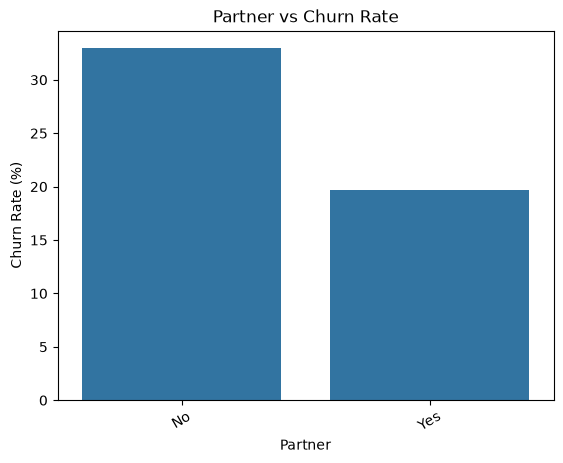

In [19]:
plot_churn_rate('Partner')

Customers without a partner have a higher churn rate of 32.96%, compared to 19.66% for customers with a partner.

In [20]:
#Grouping Tenure into bins for better visualization
df['TenureGroup'] = pd.cut(
    df['Tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'],
    include_lowest=True
)

In [21]:
churn_rate('TenureGroup')

TenureGroup
0-12     47.438243
13-24    28.710938
25-36    21.634615
37-48    19.028871
49-60    14.423077
61-72     6.609808
Name: Yes, dtype: float64

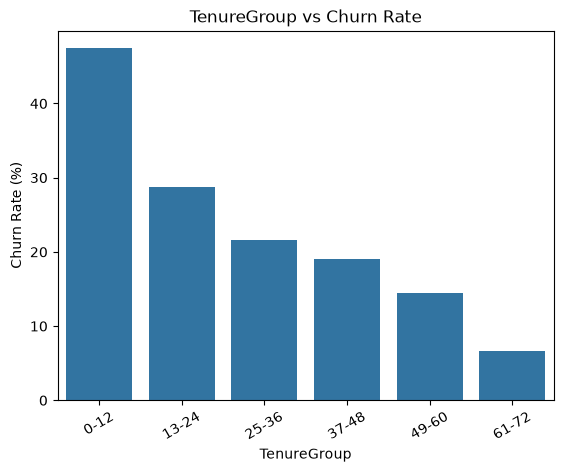

In [22]:
plot_churn_rate('TenureGroup')

Customers with shorter tenure generally have higher churn rates. The churn rate is highest during the first few months, while customers with longer tenure have much lower churn rates. For example, customers with 1 month of tenure have a churn rate of 61.99%, compared with just 1.66% for customers with 72 months of tenure.

In [23]:
#Grouping MonthlyCharges into bins for better analysis
df['MonthlyChargesGroup'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 30, 60, 90, 120],
    labels=['0-30', '30-60', '60-90', '90-120']
)

In [24]:
churn_rate('MonthlyChargesGroup')

MonthlyChargesGroup
0-30       9.800363
30-60     25.928854
60-90     33.906119
90-120    32.777458
Name: Yes, dtype: float64

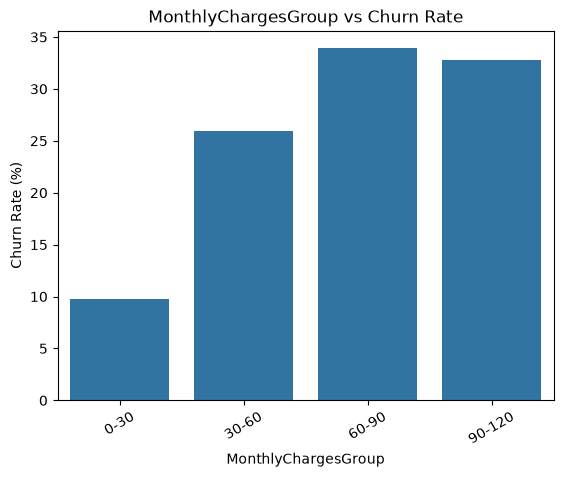

In [25]:
plot_churn_rate('MonthlyChargesGroup')

Customers with monthly charges between 0–30 have the lowest churn rate at 9.80%. Churn increases to 25.93% for charges between 30–60 and reaches the highest rate of 33.91% for charges between 60–90. The churn rate remains similar at 32.78% for charges between 90–120.

In [26]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [27]:
#Grouping TotalCharges into bins for better analysis
df['TotalChargesGroup'] = pd.cut(
    df['TotalCharges'],
    bins=[0, 1000, 2000, 3000, 4000, 5000, 6000, 8000, 10000],
    labels=['0-1000', '1000-2000', '2000-3000', '3000-4000',
            '4000-5000', '5000-6000', '6000-8000', '8000-10000'],
    include_lowest=True
)

In [28]:
churn_rate('TotalChargesGroup')

TotalChargesGroup
0-1000        36.985828
1000-2000     20.966485
2000-3000     27.607362
3000-4000     19.244604
4000-5000     16.764133
5000-6000     15.575621
6000-8000     13.843648
8000-10000     3.846154
Name: Yes, dtype: float64

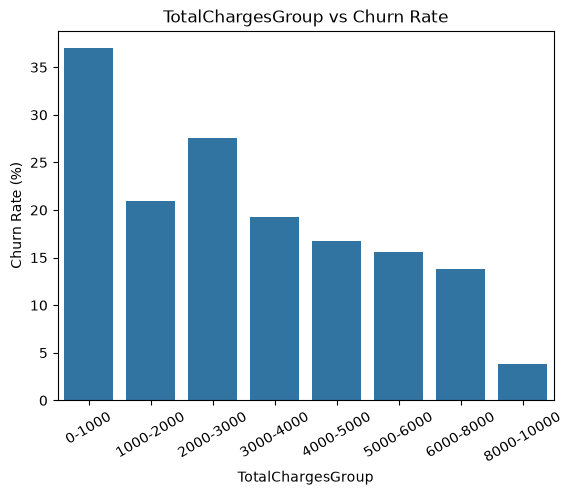

In [29]:
plot_churn_rate('TotalChargesGroup')

Customers with total charges between 0–1000 have the highest churn rate at around 37%. The churn rate generally decreases as total charges increase, with customers in the 8000–10000 range having the lowest churn rate at around 4%.

#### Variable Distribution

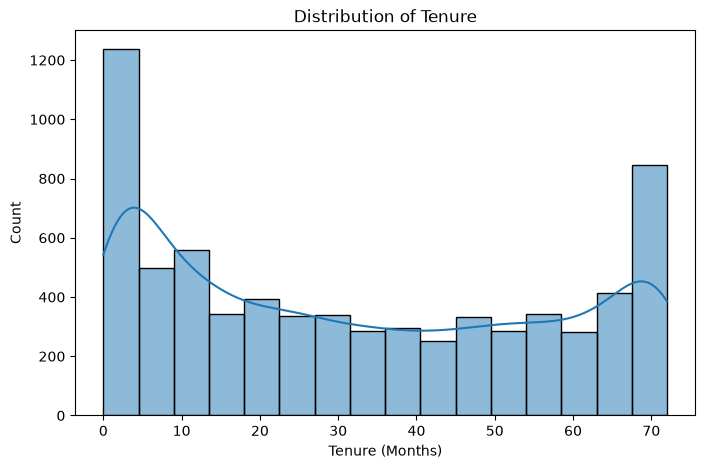

In [30]:
#Distribution of Tenure
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Tenure', kde=True)
plt.title('Distribution of Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()

Tenure is spread across 0 to 72 months, with a large number of customers having very low tenure. The number of customers is also relatively high at the higher end, around 70–72 months.

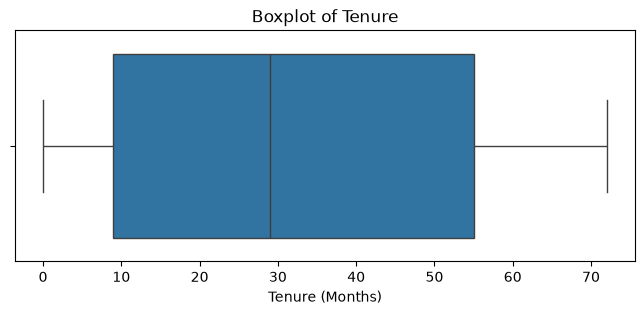

In [31]:
#Boxplot of Tenure
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x='Tenure')
plt.title('Boxplot of Tenure')
plt.xlabel('Tenure (Months)')
plt.show()

The tenure values range from 0 to 72 months, with most customers falling between around 10 and 55 months. There are no clear outliers in the tenure data.

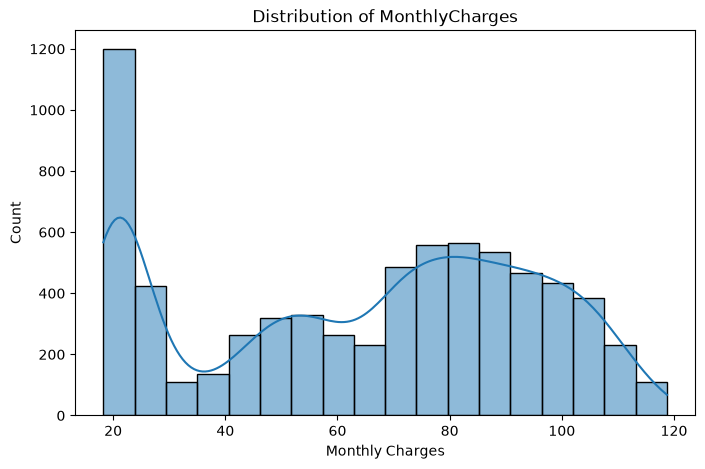

In [32]:
#Distribution of MonthlyCharges
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='MonthlyCharges', kde=True)
plt.title('Distribution of MonthlyCharges')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.show()

Monthly charges range from around 18 to 120, with many customers having charges around 20 and 70–100. The distribution has a noticeable concentration at the lower charges and another larger concentration around 70–100.

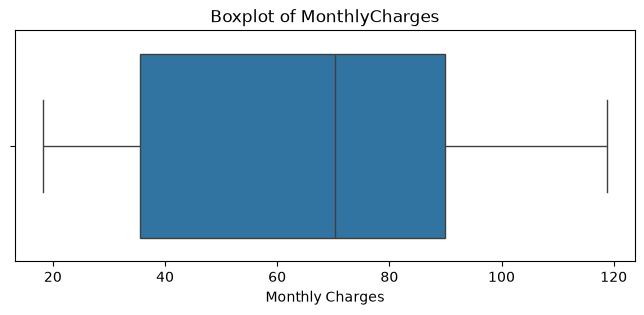

In [33]:
#Boxplot of MonthlyCharges
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x='MonthlyCharges')
plt.title('Boxplot of MonthlyCharges')
plt.xlabel('Monthly Charges')
plt.show()

The monthly charges range from around 18 to 120, with most customers having charges between about 35 and 90. There are no clear outliers in the monthly charges.

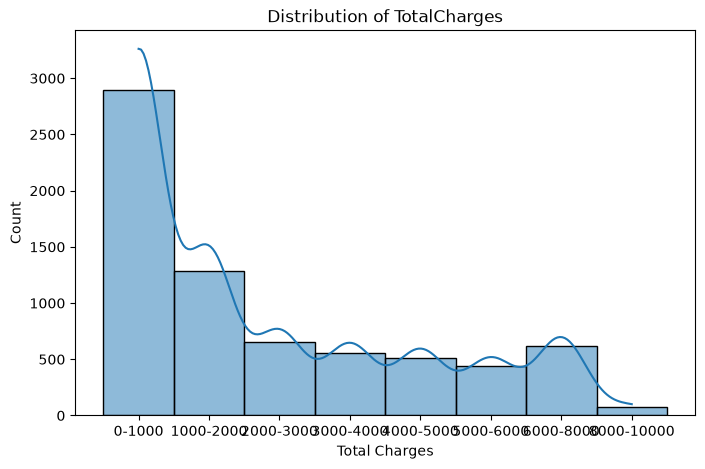

In [34]:
#Distribution of TotalChargesGroup
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='TotalChargesGroup', kde=True)
plt.title('Distribution of TotalCharges')
plt.xlabel('Total Charges')
plt.ylabel('Count')
plt.show()

Most customers have lower total charges, especially between 0–1000. The number of customers decreases as total charges increase, with fewer customers having very high total charges.

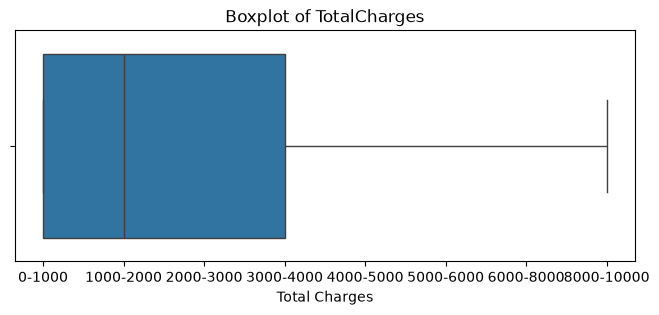

In [35]:
#Boxplot of TotalChargesGroup
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x='TotalChargesGroup')
plt.title('Boxplot of TotalCharges')
plt.xlabel('Total Charges')
plt.show()

Most customers have lower total charges, mainly below 3000. The boxplot shows that total charges are spread over a wide range, with no clear individual outliers.

#### Correlation

In [36]:
corr = df.select_dtypes(include='number').corr()

In [37]:
corr

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
Tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


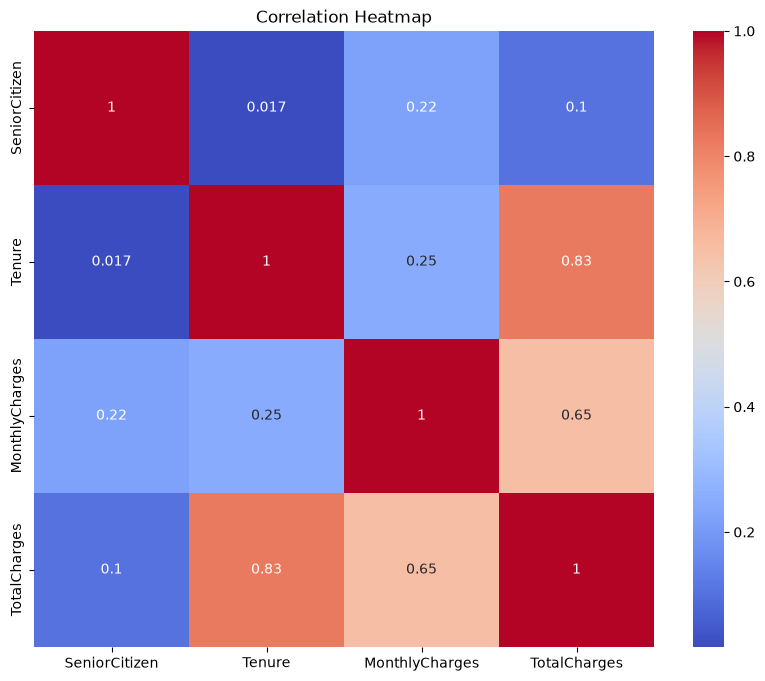

In [38]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

* Tenure and TotalCharges have a strong positive correlation of 0.83.
* MonthlyCharges and TotalCharges have a moderate positive correlation of 0.65.
* Tenure and MonthlyCharges have a weak positive correlation of 0.25.
* SeniorCitizen has very weak correlation with the other numerical variables.

#### Interaction Analysis

In [39]:
#Function to plot interaction between two categorical variables and their effect on churn rate
def interaction_churn(col1, col2):
    data = pd.crosstab(
        [df[col1], df[col2]],
        df['Churn'],
        normalize='index'
    )['Yes'].reset_index()
    sns.barplot(data=data, x=col1, y='Yes', hue=col2)
    plt.title(f'{col1} + {col2} vs Churn Rate')
    plt.ylabel('Churn Rate (%)')
    plt.xlabel(col1)
    plt.xticks(rotation=45)
    plt.show()

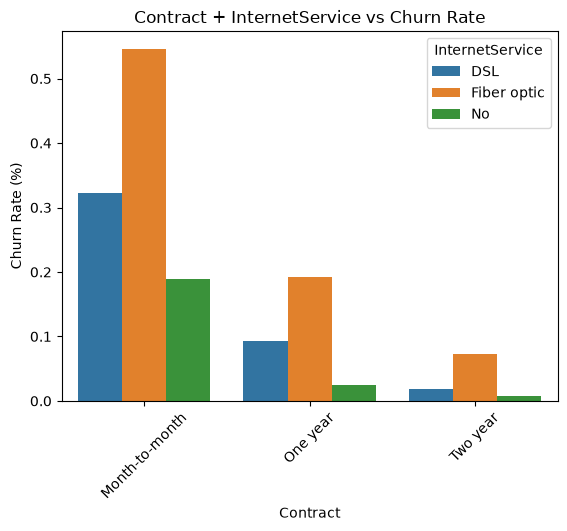

In [40]:
interaction_churn('Contract', 'InternetService')

* Month-to-month contracts have the highest churn across all internet service types.
* Fiber optic customers have the highest churn, especially those on month-to-month contracts.
* Churn is much lower for one-year and two-year contracts.
* Customers with longer contracts are less likely to churn, regardless of internet service.

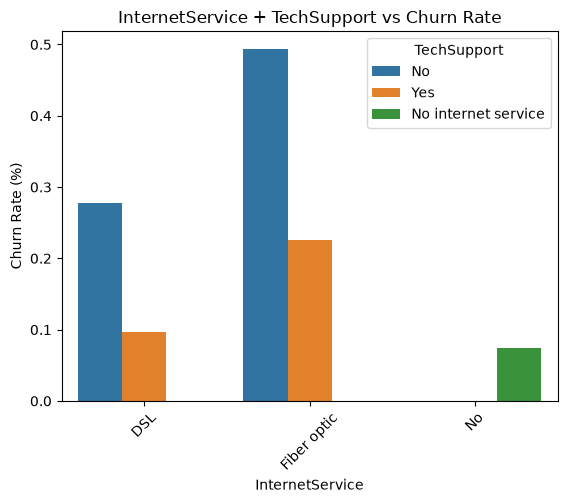

In [41]:
interaction_churn('InternetService', 'TechSupport')

* Customers without tech support have a higher churn rate for both DSL and fiber optic services.
* Fiber optic customers without tech support have the highest churn rate at around 49%.
* Customers with tech support have lower churn rates compared to those without tech support.
* Customers without internet service have a low churn rate.

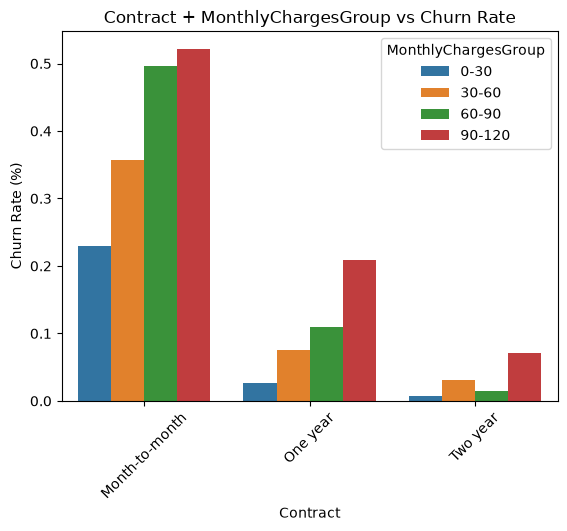

In [42]:
interaction_churn('Contract', 'MonthlyChargesGroup')

* Month-to-month customers have the highest churn rate across all monthly charge groups.
* For month-to-month contracts, churn increases as monthly charges increase.
* One-year and two-year contract customers have much lower churn rates.
* The highest churn is seen among month-to-month customers with monthly charges between 90–120.

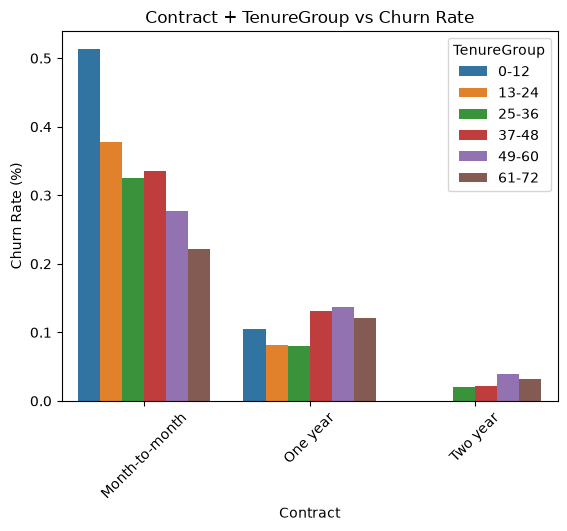

In [43]:
interaction_churn('Contract', 'TenureGroup')

* Customers with month-to-month contracts have the highest churn across all tenure groups.
* For month-to-month contracts, churn is highest for customers with 0–12 months of tenure.
* Churn is much lower for one-year and two-year contracts.
* Customers with shorter tenure and shorter contracts are more likely to churn.


#### Final EDA Summary

* Customers with month-to-month contracts are more likely to churn.
* Fiber optic customers have a higher churn rate than DSL customers.
* Customers with low tenure are more likely to churn.
* Churn is higher for customers using electronic check as their payment method.
* Customers without TechSupport or OnlineSecurity have higher churn.
* Senior citizens have a higher churn rate than non-senior citizens.
* Customers without a partner have a higher churn rate.
* Customers with higher monthly charges are more likely to churn.
* Customers with lower total charges have higher churn.
* Month-to-month customers with fiber optic service have especially high churn.
* Fiber optic customers without TechSupport have high churn.
* Month-to-month customers with high monthly charges have the highest churn.
* Customers with short tenure and month-to-month contracts are more likely to churn.
* Tenure and TotalCharges have a strong positive relationship (0.83).
* MonthlyCharges and TotalCharges have a moderate positive relationship (0.65).
* Tenure ranges from 0 to 72 months, while MonthlyCharges range from about 18 to 120.
* Most customers have lower TotalCharges, and fewer customers have very high TotalCharges.

### Data Preprocessing & Feature Engineering

In [44]:
df.isnull().sum()

customerID              0
gender                  0
SeniorCitizen           0
Partner                 0
Dependents              0
Tenure                  0
PhoneService            0
MultipleLines           0
InternetService         0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
Contract                0
PaperlessBilling        0
PaymentMethod           0
MonthlyCharges          0
TotalCharges           11
Churn                   0
TenureGroup             0
MonthlyChargesGroup     0
TotalChargesGroup      11
dtype: int64

In [45]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,MonthlyChargesGroup,TotalChargesGroup
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0-12,30-60,NaN
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,Two year,No,Mailed check,20.25,NaN,No,0-12,0-30,NaN
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,Two year,No,Mailed check,80.85,NaN,No,0-12,60-90,NaN
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,Two year,No,Mailed check,25.75,NaN,No,0-12,0-30,NaN
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,No,Two year,No,Credit card (automatic),56.05,NaN,No,0-12,30-60,NaN
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,Two year,No,Mailed check,19.85,NaN,No,0-12,0-30,NaN
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,Two year,No,Mailed check,25.35,NaN,No,0-12,0-30,NaN
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,Two year,No,Mailed check,20.00,NaN,No,0-12,0-30,NaN
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,One year,Yes,Mailed check,19.70,NaN,No,0-12,0-30,NaN
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,No,Two year,No,Mailed check,73.35,NaN,No,0-12,60-90,NaN


In [46]:
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

In [47]:
df.isnull().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
Tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
TenureGroup            0
MonthlyChargesGroup    0
TotalChargesGroup      0
dtype: int64

In [48]:
#Dropping unnecessary columns
df = df.drop(['customerID','MonthlyChargesGroup','TenureGroup','TotalChargesGroup'],axis=1)

In [49]:
df.shape

(7032, 20)

In [50]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [51]:
#Creating a new feature 'Family' which indicates if a customer has both a partner and dependents
df['Family'] = ((df['Partner'] == 'Yes') & (df['Dependents'] == 'Yes')).astype(int)

In [52]:
service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

In [53]:
#Creating a new feature 'TotalServices' which counts the number of services a customer has opted for
df['TotalServices'] = (df[service_cols] == 'Yes').sum(axis=1)

In [54]:
#Converting binary categorical variables to numeric
binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

In [55]:
for col in binary_cols:
    print(col, df[col].unique())

Partner <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PaperlessBilling <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Churn <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [56]:
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0}).astype(int)

In [57]:
df[binary_cols].dtypes

Partner             int64
Dependents          int64
PhoneService        int64
PaperlessBilling    int64
Churn               int64
dtype: object

In [58]:
dummy_columns=[
        'gender',
        'MultipleLines',
        'InternetService',
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies',
        'Contract',
        'PaymentMethod'
]

In [59]:
#Creating dummy variables for categorical columns
df = pd.get_dummies(df, columns=dummy_columns, drop_first=True)

In [60]:
#Separating features and target variable
X = df.drop('Churn', axis=1)
y = df['Churn'].astype(int)

In [61]:
#Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [62]:
X_train.select_dtypes(include='object').columns

Index([], dtype='str')

### Models

#### Logistic Regression(Baseline)

In [63]:
#Scaling the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
logistic_model = LogisticRegression(class_weight='balanced',random_state=42)

In [65]:
logistic_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [66]:
y_pred = logistic_model.predict(X_test_scaled)
y_pred_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [67]:
logistic_accuracy = accuracy_score(y_test, y_pred) * 100
print("Accuracy:", logistic_accuracy)

Accuracy: 72.56574271499645


In [68]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [69]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[724 309]
 [ 77 297]]


In [70]:
logistic_roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC:", logistic_roc_auc)

ROC-AUC: 0.834911813885107


In [71]:
logistic_recall = recall_score(y_test, y_pred)
logistic_f1 = f1_score(y_test, y_pred)

In [72]:
print("Logistic Regression Recall:", logistic_recall)
print("Logistic Regression F1:", logistic_f1)

Logistic Regression Recall: 0.7941176470588235
Logistic Regression F1: 0.6061224489795919


#### Decision Tree

In [73]:
decision_tree_model = DecisionTreeClassifier(class_weight='balanced',random_state=42)

In [74]:
decision_tree_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are 

In [75]:
y_pred_dt = decision_tree_model.predict(X_test)
y_pred_proba_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [76]:
decision_tree_accuracy = accuracy_score(y_test, y_pred_dt) * 100
print("Accuracy:", decision_tree_accuracy)

Accuracy: 73.0632551528074


In [77]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1033
           1       0.49      0.47      0.48       374

    accuracy                           0.73      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407



In [78]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))


Confusion Matrix:
[[852 181]
 [198 176]]


In [79]:
decision_tree_roc_auc = roc_auc_score(y_test, y_pred_proba_dt)
print("\nROC-AUC:", decision_tree_roc_auc)


ROC-AUC: 0.6481342955205492


In [80]:
decision_tree_recall = recall_score(y_test, y_pred_dt)
decision_tree_f1 = f1_score(y_test, y_pred_dt)

In [81]:
print("Decision Tree Recall:", decision_tree_recall)
print("Decision Tree F1:", decision_tree_f1)

Decision Tree Recall: 0.47058823529411764
Decision Tree F1: 0.48153214774281805


#### Random Forest

In [82]:
random_forest_model = RandomForestClassifier(class_weight='balanced',random_state=42)

In [83]:
random_forest_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [84]:
y_pred_rf = random_forest_model.predict(X_test)
y_pred_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [85]:
random_forest_accuracy = accuracy_score(y_test, y_pred_rf) * 100
print("Accuracy:", random_forest_accuracy)

Accuracy: 76.83013503909027


In [86]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1033
           1       0.56      0.65      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.77      1407



In [87]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


Confusion Matrix:
[[839 194]
 [132 242]]


In [88]:
random_forest_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)
print("\nROC-AUC:", random_forest_roc_auc)


ROC-AUC: 0.8188392667636445


In [89]:
random_forest_recall = recall_score(y_test, y_pred_rf)
random_forest_f1 = f1_score(y_test, y_pred_rf)

In [90]:
print("Random Forest Recall:", random_forest_recall)
print("Random Forest F1:", random_forest_f1)

Random Forest Recall: 0.6470588235294118
Random Forest F1: 0.5975308641975309


#### XGBM

In [91]:
xgb_model = XGBClassifier(scale_pos_weight=5163 / 1869,random_state=42,eval_metric='logloss')

In [92]:
xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [93]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [94]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb) * 100
print("Accuracy:", xgb_accuracy)

Accuracy: 74.84008528784648


In [95]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1033
           1       0.52      0.68      0.59       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.70      1407
weighted avg       0.78      0.75      0.76      1407



In [96]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))


Confusion Matrix:
[[798 235]
 [119 255]]


In [97]:
xgb_roc_auc = roc_auc_score(y_test, y_pred_proba_xgb)
print("\nROC-AUC:", xgb_roc_auc)


ROC-AUC: 0.8172823560472326


In [98]:
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

In [99]:
print("XGBoost Recall:", xgb_recall)
print("XGBoost F1:", xgb_f1)

XGBoost Recall: 0.6818181818181818
XGBoost F1: 0.5902777777777778


#### LGBM

In [100]:
lgbm_model = LGBMClassifier(class_weight='balanced',random_state=42,verbosity=-1)

In [101]:
lgbm_model.fit(X_train, y_train)

,class_weight,'balanced'
,random_state,42
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,min_split_gain,0.0


In [102]:
y_pred_lgbm = lgbm_model.predict(X_test)
y_pred_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

In [103]:
lgbm_accuracy = accuracy_score(y_test, y_pred_lgbm) * 100
print("Accuracy:", lgbm_accuracy)

Accuracy: 74.6268656716418


In [104]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.52      0.76      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407



In [105]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))


Confusion Matrix:
[[766 267]
 [ 90 284]]


In [106]:
lgbm_roc_auc = roc_auc_score(y_test, y_pred_proba_lgbm)
print("\nROC-AUC:", lgbm_roc_auc)


ROC-AUC: 0.8295732796330713


In [107]:
lgbm_recall = recall_score(y_test, y_pred_lgbm)
lgbm_f1 = f1_score(y_test, y_pred_lgbm)

In [108]:
print("LightGBM Recall:", lgbm_recall)
print("LightGBM F1:", lgbm_f1)

LightGBM Recall: 0.7593582887700535
LightGBM F1: 0.614054054054054


#### Comparison Table

In [109]:
before_tuning = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'LightGBM'
    ],
    'Accuracy (%)': [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        xgb_accuracy,
        lgbm_accuracy
    ],
    'Churn Recall': [
        logistic_recall,
        decision_tree_recall,
        random_forest_recall,
        xgb_recall,
        lgbm_recall
    ],
    'Churn F1': [
        logistic_f1,
        decision_tree_f1,
        random_forest_f1,
        xgb_f1,
        lgbm_f1
    ],
    'ROC-AUC': [
        logistic_roc_auc,
        decision_tree_roc_auc,
        random_forest_roc_auc,
        xgb_roc_auc,
        lgbm_roc_auc
    ]
})

In [110]:
before_tuning

,Model,Accuracy (%),Churn Recall,Churn F1,ROC-AUC
0,Logistic Regression,72.565743,0.794118,0.606122,0.834912
1,Decision Tree,73.063255,0.470588,0.481532,0.648134
2,Random Forest,76.830135,0.647059,0.597531,0.818839
3,XGBoost,74.840085,0.681818,0.590278,0.817282
4,LightGBM,74.626866,0.759358,0.614054,0.829573


### Hyper-Parameter Tuning

#### Logistic Regression

In [111]:
logistic = LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000)

In [112]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

In [113]:
logistic_random = RandomizedSearchCV(
    estimator=logistic,
    param_distributions=param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [114]:
logistic_random.fit(X_train_scaled, y_train)

c:\Users\Videep\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.001, 0.01, ...], 'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_i

In [115]:
print("Best Parameters:")
print(logistic_random.best_params_)

Best Parameters:
{'solver': 'liblinear', 'penalty': 'l2', 'C': 100}


In [116]:
print("Best CV ROC-AUC:")
print(logistic_random.best_score_)

Best CV ROC-AUC:
0.8448982483986169


In [117]:
tuned_logistic = logistic_random.best_estimator_
y_pred_tuned_logistic = tuned_logistic.predict(X_test_scaled)
y_pred_proba_tuned_logistic = tuned_logistic.predict_proba(X_test_scaled)[:, 1]

In [118]:
tuned_logistic_accuracy = accuracy_score(y_test, y_pred_tuned_logistic)*100
tuned_logistic_recall = recall_score(y_test, y_pred_tuned_logistic)
tuned_logistic_f1 = f1_score(y_test, y_pred_tuned_logistic)
tuned_logistic_roc_auc = roc_auc_score(y_test, y_pred_proba_tuned_logistic)
tuned_logistic_precision = precision_score(y_test, y_pred_tuned_logistic)

In [119]:
print("Accuracy:", tuned_logistic_accuracy)
print("Churn Recall:", tuned_logistic_recall)
print("Churn F1:", tuned_logistic_f1)
print("ROC-AUC:", tuned_logistic_roc_auc)
print("Precision: ", tuned_logistic_precision)

Accuracy: 72.42359630419331
Churn Recall: 0.7967914438502673
Churn F1: 0.6056910569105691
ROC-AUC: 0.8342233047403596
Precision:  0.4885245901639344


#### Decision Tree

In [120]:
dt = DecisionTreeClassifier(class_weight='balanced',random_state=42)

In [121]:
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8, 10],
    'max_features': [None, 'sqrt', 'log2']
}

In [122]:
dt_random = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [123]:
dt_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instanc

In [124]:
print("Best Parameters:")
print(dt_random.best_params_)

Best Parameters:
{'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': None, 'max_depth': 5, 'criterion': 'gini'}


In [125]:
print("\nBest CV ROC-AUC:")
print(dt_random.best_score_)


Best CV ROC-AUC:
0.8312142168811292


In [126]:
tuned_dt = dt_random.best_estimator_
y_pred_tuned_dt = tuned_dt.predict(X_test)
y_pred_proba_tuned_dt = tuned_dt.predict_proba(X_test)[:, 1]

In [127]:
tuned_dt_accuracy = accuracy_score(y_test, y_pred_tuned_dt) * 100
tuned_dt_recall = recall_score(y_test, y_pred_tuned_dt)
tuned_dt_f1 = f1_score(y_test, y_pred_tuned_dt)
tuned_dt_roc_auc = roc_auc_score(y_test, y_pred_proba_tuned_dt)
tuned_dt_precision = precision_score(y_test, y_pred_tuned_dt)

In [128]:
print("Accuracy:", tuned_dt_accuracy)
print("Churn Recall:", tuned_dt_recall)
print("Churn F1:", tuned_dt_f1)
print("ROC-AUC:", tuned_dt_roc_auc)
print("Precision: ", tuned_dt_precision)

Accuracy: 70.43354655294954
Churn Recall: 0.7834224598930482
Churn F1: 0.5848303393213573
ROC-AUC: 0.817536017311087
Precision:  0.46656050955414013


#### Random Forest

In [129]:
rf = RandomForestClassifier(class_weight='balanced',random_state=42)

In [130]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [131]:
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [132]:
rf_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Als

In [133]:
print("Best Parameters:")
print(rf_random.best_params_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}


In [134]:
print("\nBest CV ROC-AUC:")
print(rf_random.best_score_)


Best CV ROC-AUC:
0.844711184173233


In [135]:
tuned_rf = rf_random.best_estimator_
y_pred_tuned_rf = tuned_rf.predict(X_test)
y_pred_proba_tuned_rf = tuned_rf.predict_proba(X_test)[:, 1]

In [136]:
tuned_rf_accuracy = accuracy_score(y_test, y_pred_tuned_rf) * 100
tuned_rf_recall = recall_score(y_test, y_pred_tuned_rf)
tuned_rf_f1 = f1_score(y_test, y_pred_tuned_rf)
tuned_rf_roc_auc = roc_auc_score(y_test, y_pred_proba_tuned_rf)
tuned_rf_precision = precision_score(y_test, y_pred_tuned_rf)

In [137]:
print("Accuracy:", tuned_rf_accuracy)
print("Churn Recall:", tuned_rf_recall)
print("Churn F1:", tuned_rf_f1)
print("ROC-AUC:", tuned_rf_roc_auc)
print("Precision: ", tuned_rf_precision)

Accuracy: 74.69793887704336
Churn Recall: 0.7887700534759359
Churn F1: 0.6236786469344608
ROC-AUC: 0.836366483581904
Precision:  0.5157342657342657


#### XGBM

In [138]:
#Scale positive weight for XGBoost based on class imbalance
xgb = XGBClassifier(scale_pos_weight=5163/1869,random_state=42,eval_metric='logloss')

In [139]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'gamma': [0, 0.1, 0.3, 0.5]
}

In [140]:
xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [141]:
xgb_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for

In [142]:
print("Best Parameters:")
print(xgb_random.best_params_)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}


In [143]:
print("\nBest CV ROC-AUC:")
print(xgb_random.best_score_)


Best CV ROC-AUC:
0.8474685594435043


In [144]:
tuned_xgb = xgb_random.best_estimator_
y_pred_tuned_xgb = tuned_xgb.predict(X_test)
y_pred_proba_tuned_xgb = tuned_xgb.predict_proba(X_test)[:, 1]

In [145]:
tuned_xgb_accuracy = accuracy_score(y_test, y_pred_tuned_xgb) * 100
tuned_xgb_recall = recall_score(y_test, y_pred_tuned_xgb)
tuned_xgb_f1 = f1_score(y_test, y_pred_tuned_xgb)
tuned_xgb_roc_auc = roc_auc_score(y_test, y_pred_proba_tuned_xgb)
tuned_xgb_precision = precision_score(y_test, y_pred_tuned_xgb)

In [146]:
print("Accuracy:", tuned_xgb_accuracy)
print("Churn Recall:", tuned_xgb_recall)
print("Churn F1:", tuned_xgb_f1)
print("ROC-AUC:", tuned_xgb_roc_auc)
print("Precision: ", tuned_xgb_precision)

Accuracy: 73.41862117981522
Churn Recall: 0.8181818181818182
Churn F1: 0.6206896551724138
ROC-AUC: 0.8407408461932692
Precision:  0.5


#### LGBM

In [147]:
lgbm = LGBMClassifier(class_weight='balanced',random_state=42,verbosity=-1)

In [148]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [-1, 3, 5, 7, 10],
    'num_leaves': [15, 31, 50, 70],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

In [149]:
lgbm_random = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [150]:
lgbm_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 3, ...], 'min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instan

In [151]:
print("Best Parameters:")
print(lgbm_random.best_params_)

Best Parameters:
{'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 30, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [152]:
print("\nBest CV ROC-AUC:")
print(lgbm_random.best_score_)


Best CV ROC-AUC:
0.8473948674759286


In [153]:
tuned_lgbm = lgbm_random.best_estimator_
y_pred_tuned_lgbm = tuned_lgbm.predict(X_test)
y_pred_proba_tuned_lgbm = tuned_lgbm.predict_proba(X_test)[:, 1]

In [154]:
tuned_lgbm_accuracy = accuracy_score(y_test, y_pred_tuned_lgbm) * 100
tuned_lgbm_recall = recall_score(y_test, y_pred_tuned_lgbm)
tuned_lgbm_f1 = f1_score(y_test, y_pred_tuned_lgbm)
tuned_lgbm_roc_auc = roc_auc_score(y_test, y_pred_proba_tuned_lgbm)
tuned_lgbm_precision = precision_score(y_test, y_pred_tuned_lgbm)

In [155]:
print("Accuracy:", tuned_lgbm_accuracy)
print("Churn Recall:", tuned_lgbm_recall)
print("Churn F1:", tuned_lgbm_f1)
print("ROC-AUC:", tuned_lgbm_roc_auc)
print("Precision: ", tuned_lgbm_precision)

Accuracy: 72.99218194740583
Churn Recall: 0.8074866310160428
Churn F1: 0.6138211382113821
ROC-AUC: 0.8392848823063503
Precision:  0.49508196721311476


#### Comparison Table

In [156]:
after_tuning = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'LightGBM'
    ],
    'Accuracy (%)': [
        tuned_logistic_accuracy,
        tuned_dt_accuracy,
        tuned_rf_accuracy,
        tuned_xgb_accuracy,
        tuned_lgbm_accuracy
    ],
    'Churn Recall': [
        tuned_logistic_recall,
        tuned_dt_recall,
        tuned_rf_recall,
        tuned_xgb_recall,
        tuned_lgbm_recall
    ],
    'Churn F1': [
        tuned_logistic_f1,
        tuned_dt_f1,
        tuned_rf_f1,
        tuned_xgb_f1,
        tuned_lgbm_f1
    ],
    'ROC-AUC': [
        tuned_logistic_roc_auc,
        tuned_dt_roc_auc,
        tuned_rf_roc_auc,
        tuned_xgb_roc_auc,
        tuned_lgbm_roc_auc
    ]
})

In [157]:
after_tuning

,Model,Accuracy (%),Churn Recall,Churn F1,ROC-AUC
0,Logistic Regression,72.423596,0.796791,0.605691,0.834223
1,Decision Tree,70.433547,0.783422,0.584830,0.817536
2,Random Forest,74.697939,0.788770,0.623679,0.836366
3,XGBoost,73.418621,0.818182,0.620690,0.840741
4,LightGBM,72.992182,0.807487,0.613821,0.839285


### Old vs New Models

In [158]:
#Comparing the accuracy of models before and after hyperparameter tuning
accuracy_comparison = pd.DataFrame({
    'Model': before_tuning['Model'],
    'Before Tuning': before_tuning['Accuracy (%)'],
    'After Tuning': after_tuning['Accuracy (%)']
})
accuracy_comparison

,Model,Before Tuning,After Tuning
0,Logistic Regression,72.565743,72.423596
1,Decision Tree,73.063255,70.433547
2,Random Forest,76.830135,74.697939
3,XGBoost,74.840085,73.418621
4,LightGBM,74.626866,72.992182


In [159]:
#Comparing Precision, Recall and F1-score before and after hyperparameter tuning
precision_comparison = pd.DataFrame({
    'Model': before_tuning['Model'],
    'Before Tuning': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgbm)
    ],
    'After Tuning': [
        precision_score(y_test, y_pred_tuned_logistic),
        precision_score(y_test, y_pred_tuned_dt),
        precision_score(y_test, y_pred_tuned_rf),
        precision_score(y_test, y_pred_tuned_xgb),
        precision_score(y_test, y_pred_tuned_lgbm)
    ]
})

recall_comparison = pd.DataFrame({
    'Model': before_tuning['Model'],
    'Before Tuning': before_tuning['Churn Recall'],
    'After Tuning': after_tuning['Churn Recall']
})

f1_comparison = pd.DataFrame({
    'Model': before_tuning['Model'],
    'Before Tuning': before_tuning['Churn F1'],
    'After Tuning': after_tuning['Churn F1']
})

print("Precision Comparison")
display(precision_comparison)

print("Recall Comparison")
display(recall_comparison)

print("F1-score Comparison")
display(f1_comparison)

Precision Comparison


,Model,Before Tuning,After Tuning
0,Logistic Regression,0.490099,0.488525
1,Decision Tree,0.492997,0.466561
2,Random Forest,0.555046,0.515734
3,XGBoost,0.520408,0.500000
4,LightGBM,0.515426,0.495082


Recall Comparison


,Model,Before Tuning,After Tuning
0,Logistic Regression,0.794118,0.796791
1,Decision Tree,0.470588,0.783422
2,Random Forest,0.647059,0.788770
3,XGBoost,0.681818,0.818182
4,LightGBM,0.759358,0.807487


F1-score Comparison


,Model,Before Tuning,After Tuning
0,Logistic Regression,0.606122,0.605691
1,Decision Tree,0.481532,0.584830
2,Random Forest,0.597531,0.623679
3,XGBoost,0.590278,0.620690
4,LightGBM,0.614054,0.613821


In [160]:
#Comparing the ROC-AUC of models before and after hyperparameter tuning
roc_comparison = pd.DataFrame({
    'Model': before_tuning['Model'],
    'Before Tuning': before_tuning['ROC-AUC'],
    'After Tuning': after_tuning['ROC-AUC']
})
roc_comparison

,Model,Before Tuning,After Tuning
0,Logistic Regression,0.834912,0.834223
1,Decision Tree,0.648134,0.817536
2,Random Forest,0.818839,0.836366
3,XGBoost,0.817282,0.840741
4,LightGBM,0.829573,0.839285


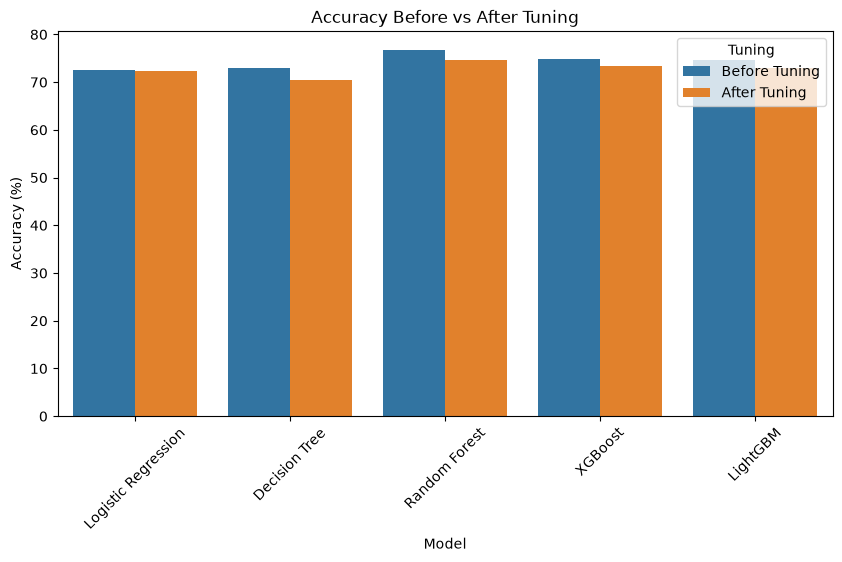

In [161]:
#Visualizing the accuracy comparison before and after hyperparameter tuning
accuracy_comparison_melted = accuracy_comparison.melt(
    id_vars='Model',
    var_name='Tuning',
    value_name='Accuracy (%)'
)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=accuracy_comparison_melted,
    x='Model',
    y='Accuracy (%)',
    hue='Tuning'
)
plt.title('Accuracy Before vs After Tuning')
plt.ylabel('Accuracy (%)')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.show()

* Accuracy decreased slightly for all models after tuning.
* Logistic Regression had almost no change in accuracy after tuning.
* Decision Tree had the largest drop in accuracy.
* Random Forest still had the highest accuracy after tuning at 74.70%.
* XGBoost showed the biggest improvement in ROC-AUC, increasing from 0.817 to 0.841.
* XGBoost also achieved the highest churn recall after tuning at 81.82%.
* LightGBM also improved its ability to identify churners, with 80.75% churn recall.
* Tuning improved ROC-AUC and churn recall for the tree-based boosting models, even though their accuracy decreased.
* XGBoost is the strongest model after tuning based on ROC-AUC and churn recall.

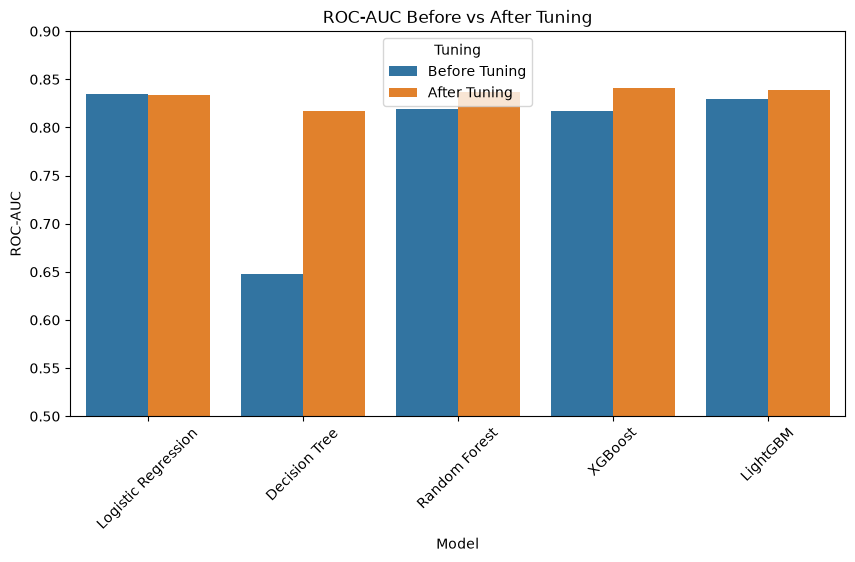

In [162]:
#Visualizing the ROC-AUC comparison before and after hyperparameter tuning
roc_comparison_melted = roc_comparison.melt(
    id_vars='Model',
    var_name='Tuning',
    value_name='ROC-AUC'
)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=roc_comparison_melted,
    x='Model',
    y='ROC-AUC',
    hue='Tuning'
)
plt.title('ROC-AUC Before vs After Tuning')
plt.ylabel('ROC-AUC')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylim(0.5, 0.9)
plt.show()

* ROC-AUC improved after tuning for Decision Tree, Random Forest, XGBoost, and LightGBM.
* Logistic Regression showed almost no change in ROC-AUC.
* Decision Tree had the biggest improvement in ROC-AUC.
* XGBoost achieved the highest ROC-AUC after tuning at 0.841.
* LightGBM also performed well with a ROC-AUC of 0.839.
* Random Forest improved slightly after tuning.
* Tuning improved the models' ability to distinguish between churned and non-churned customers.


In [ ]:
# Final comparison table - Tuned Models Only
final_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'LightGBM'
    ],
    'Accuracy': [
        tuned_logistic_accuracy,
        tuned_dt_accuracy,
        tuned_rf_accuracy,
        tuned_xgb_accuracy,
        tuned_lgbm_accuracy
    ],
    'Precision': [
        tuned_logistic_precision,
        tuned_dt_precision,
        tuned_rf_precision,
        tuned_xgb_precision,
        tuned_lgbm_precision
    ],
    'Recall': [
        tuned_logistic_recall,
        tuned_dt_recall,
        tuned_rf_recall,
        tuned_xgb_recall,
        tuned_lgbm_recall
    ],
    'F1-Score': [
        tuned_logistic_f1,
        tuned_dt_f1,
        tuned_rf_f1,
        tuned_xgb_f1,
        tuned_lgbm_f1
    ],
    'ROC-AUC': [
        tuned_logistic_roc_auc,
        tuned_dt_roc_auc,
        tuned_rf_roc_auc,
        tuned_xgb_roc_auc,
        tuned_lgbm_roc_auc
    ]
})

display(final_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,72.4236,0.4885,0.7968,0.6057,0.8342
1,Decision Tree,70.4335,0.4666,0.7834,0.5848,0.8175
2,Random Forest,74.6979,0.5157,0.7888,0.6237,0.8364
3,XGBoost,73.4186,0.5000,0.8182,0.6207,0.8407
4,LightGBM,72.9922,0.4951,0.8075,0.6138,0.8393


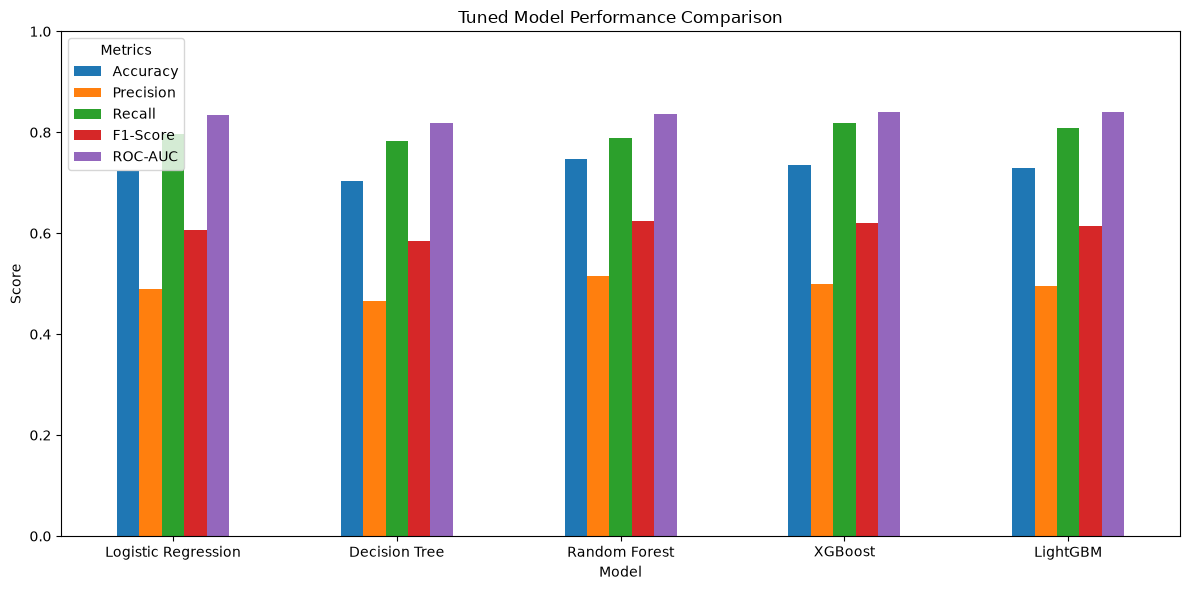

In [164]:
#Visualization of tuned model performance
plot_data = final_comparison.copy()
plot_data['Accuracy'] = plot_data['Accuracy'] / 100
plot_data.plot(
    x='Model',
    y=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    kind='bar',
    figsize=(12, 6)
)

plt.title('Tuned Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

* XGBoost has the highest recall (0.8182), meaning it identifies the highest proportion of actual churn customers.

* Random Forest has the highest accuracy (74.70%), while its ROC-AUC is also high at 0.8364.

* XGBoost has the highest ROC-AUC (0.8407), showing good overall ability to distinguish between churn and non-churn customers.

* Random Forest has the highest precision (0.5157) and F1-score (0.6237), giving a good balance between precision and recall.

* Decision Tree performs lower than the other models across most metrics, with the lowest accuracy (70.43%) and F1-score (0.5848).

Overall, the tuned models show similar performance, with ROC-AUC values above 0.81 and recall values above 0.78.


### Final Model Selection

Based on the business objective of identifying customers who are likely to churn, Recall is especially important because missing an actual churn customer can result in losing that customer.

XGBoost is selected as the final model because it has the highest Recall (0.8182) and the highest ROC-AUC (0.8407) among the tuned models. Its F1-score (0.6207) is also close to the highest F1-score of Random Forest (0.6237).

Although Random Forest has slightly higher Precision and F1-score, XGBoost identifies more actual churn customers and provides the highest overall discrimination based on ROC-AUC.

Therefore, XGBoost will be used as the final model for the churn prediction system, followed by threshold optimization to determine an appropriate probability cutoff for targeting customers for retention actions.


### Feature Importance and Model Explainability

In [167]:
#Visualizing the top 15 features based on importance from the tuned XGBoost model
feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': tuned_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance_xgb.head(15)

,Feature,Importance
28,Contract_Two year,0.338144
27,Contract_One year,0.276441
13,InternetService_Fiber optic,0.073500
14,InternetService_No,0.039682
26,StreamingMovies_Yes,0.031282
3,Tenure,0.025726
30,PaymentMethod_Electronic check,0.023733
16,OnlineSecurity_Yes,0.016668
22,TechSupport_Yes,0.015974
5,PaperlessBilling,0.014852


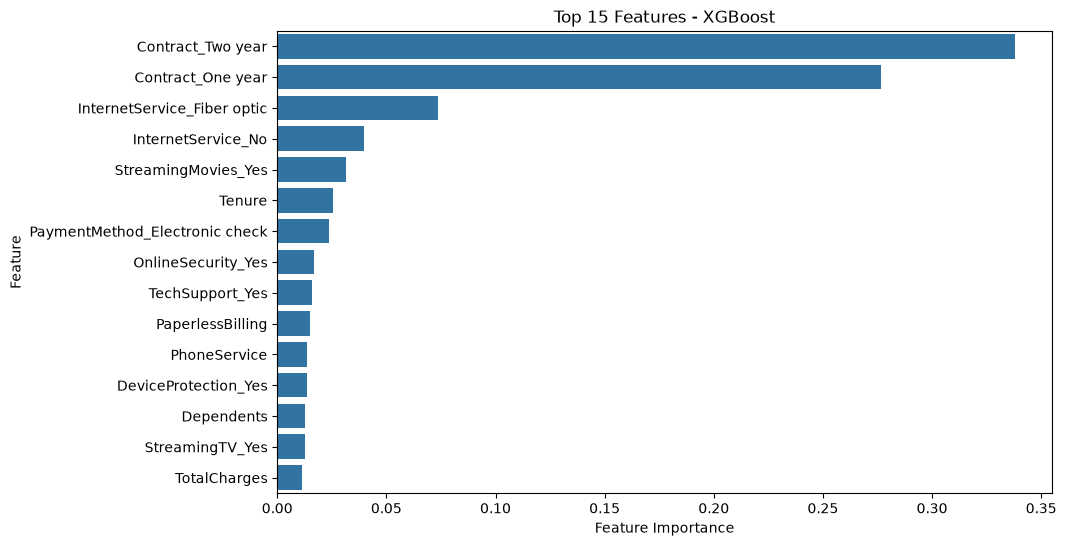

In [168]:
#Visualizing the top 15 features based on importance from the tuned XGBoost model
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_xgb.head(15),
    x='Importance',
    y='Feature'
)
plt.title('Top 15 Features - XGBoost')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.show()

### SHAP

#### SHAP Feature Importance

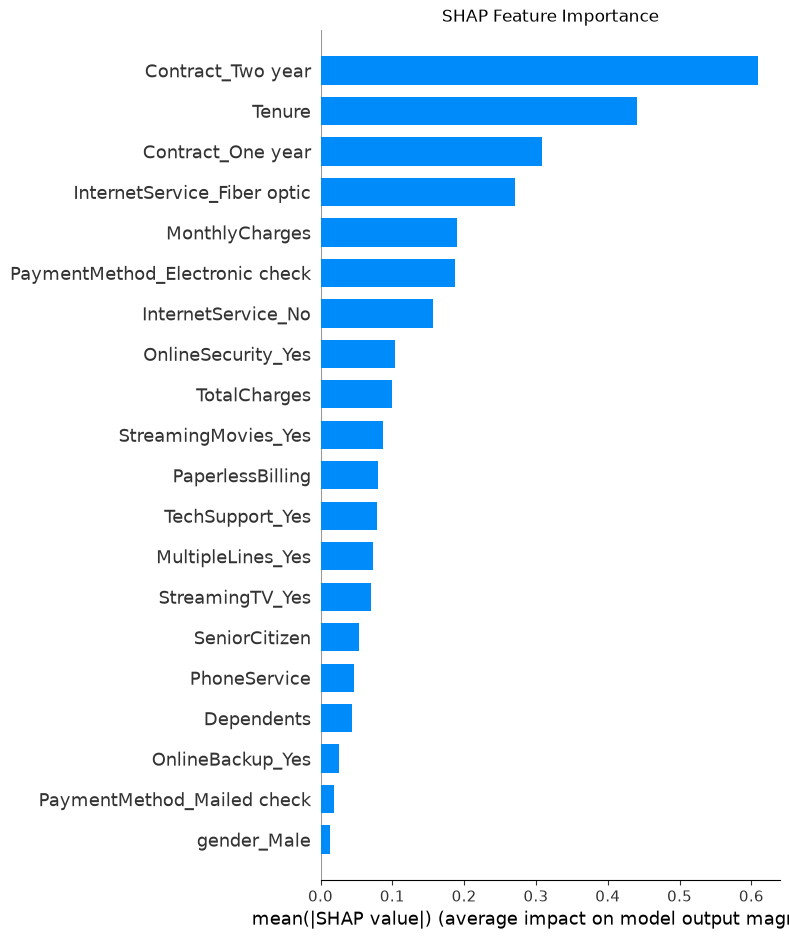

In [169]:
#Creating SHAP explainer for the final XGBoost model
explainer = shap.TreeExplainer(tuned_xgb)
shap_values = explainer.shap_values(X_test)

# SHAP feature importance
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

* Contract_Two year has the highest SHAP importance, showing that contract type has a strong influence on the model's churn predictions.

* Tenure is the second most important feature, indicating that the length of time a customer has stayed with the company strongly affects churn prediction.

* Contract_One year, InternetService_Fiber optic, and MonthlyCharges are also important features in predicting customer churn.

* PaymentMethod_Electronic check has a noticeable impact, while features such as gender, mailed check payment method, and online backup have relatively low importance.

Overall, contract type, tenure, internet service, and monthly charges are the main features influencing the XGBoost model's churn predictions.


#### SHAP Beeswarm Plot

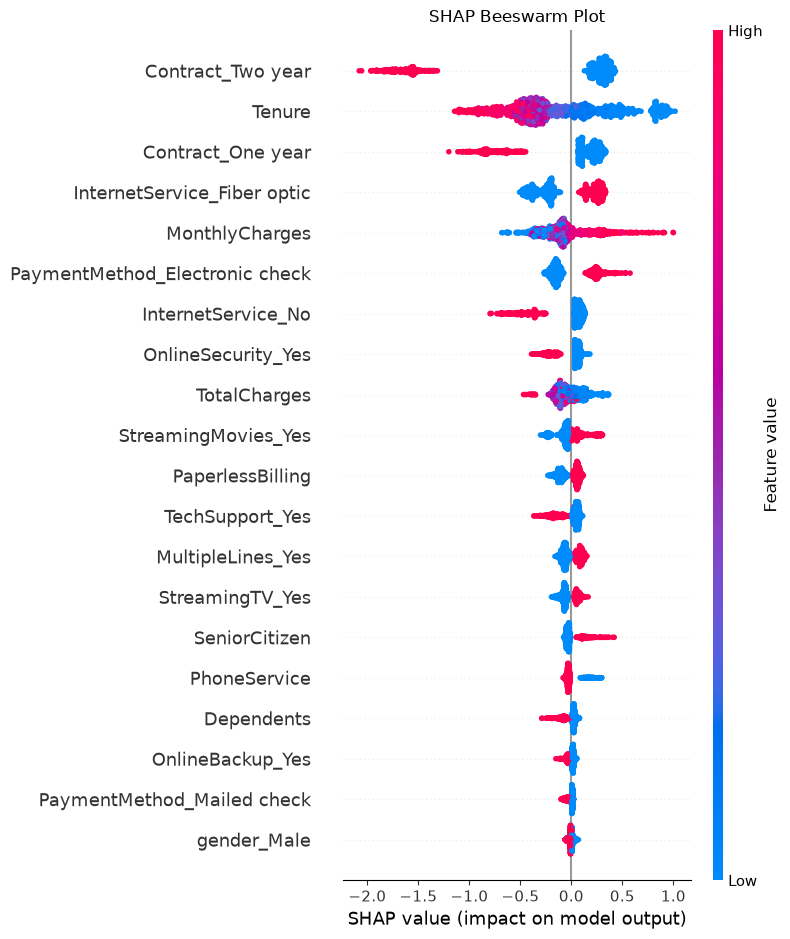

In [170]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()

* Contract_Two year has a strong negative SHAP impact when the feature value is high, indicating that customers with two-year contracts are less likely to churn.

* Tenure shows that lower tenure generally increases churn risk, while higher tenure tends to reduce the predicted churn risk.

* Higher MonthlyCharges and Electronic check payment method generally have positive SHAP values, indicating higher churn risk for these customers.

* Fiber optic internet service shows a noticeable impact, with higher feature values generally associated with increased churn risk.

Overall, contract type, tenure, monthly charges, internet service, and payment method are the main features influencing the direction of the XGBoost churn predictions.


### Threshold Optimization

In [171]:
#Churn probabilities from the final XGBoost model
y_pred_proba_xgb = y_pred_proba_tuned_xgb

In [172]:
#Testing thresholds from 0.10 to 0.90
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba_xgb >= threshold).astype(int)
    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, y_pred_threshold, zero_division=0),
        'Recall': recall_score(y_test, y_pred_threshold, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_results)
display(threshold_results.round(4))

,Threshold,Precision,Recall,F1-Score
0,0.10,0.3508,0.9840,0.5172
1,0.15,0.3699,0.9733,0.5361
2,0.20,0.3802,0.9545,0.5438
3,0.25,0.4037,0.9412,0.5650
4,0.30,0.4230,0.9251,0.5805
5,0.35,0.4436,0.8930,0.5927
6,0.40,0.4553,0.8583,0.5950
7,0.45,0.4727,0.8342,0.6035
8,0.50,0.5000,0.8182,0.6207
9,0.55,0.5316,0.7861,0.6343


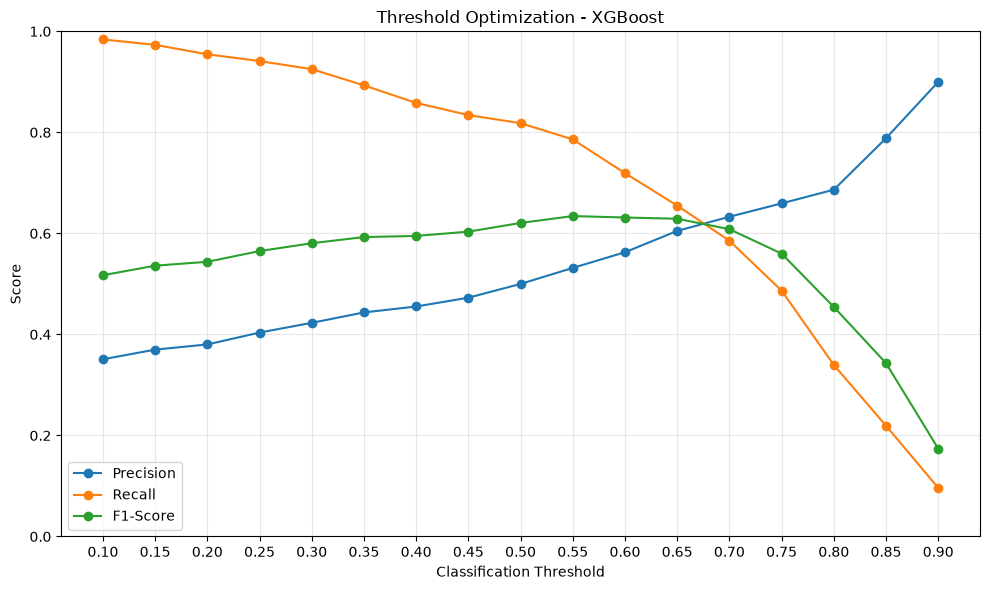

In [173]:
#Visualizing Precision, Recall, and F1-Score for different thresholds
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results['Threshold'],
    threshold_results['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_results['Threshold'],
    threshold_results['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_results['Threshold'],
    threshold_results['F1-Score'],
    marker='o',
    label='F1-Score'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimization - XGBoost')
plt.xticks(thresholds.round(2))
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

* Recall is highest at the lower thresholds and gradually decreases as the classification threshold increases.

* Precision increases with the threshold, meaning fewer non-churn customers are classified as churners.

* F1-score increases up to a threshold of 0.55, where it reaches its highest value of approximately 0.63.

* After 0.55, the F1-score starts decreasing because the reduction in Recall becomes larger than the improvement in Precision.

Overall, the threshold of 0.55 provides a good balance between Precision and Recall and is selected for the final XGBoost model.


In [174]:
best_f1_row = threshold_results.loc[
    threshold_results['F1-Score'].idxmax()
]

print("Threshold with highest F1-score:")
print(best_f1_row)

Threshold with highest F1-score:
Threshold    0.550000
Precision    0.531646
Recall       0.786096
F1-Score     0.634304
Name: 9, dtype: float64


The threshold of 0.55 is selected as the final classification threshold because it provides the highest F1-score of 0.6343 while maintaining a good Recall of 0.7861. At this threshold, Precision is 0.5316, providing a reasonable balance between identifying actual churn customers and avoiding excessive false-positive predictions. Since the project focuses on customer retention, this balance is more suitable than using a higher threshold that would significantly reduce Recall.


In [175]:
#Selecting the threshold that maximizes F1-score
selected_threshold = 0.55

y_pred_final = (
    y_pred_proba_xgb >= selected_threshold
).astype(int)

print(f"Selected Threshold: {selected_threshold}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_final):.4f}")

Selected Threshold: 0.55
Precision: 0.5316
Recall: 0.7861
F1-Score: 0.6343


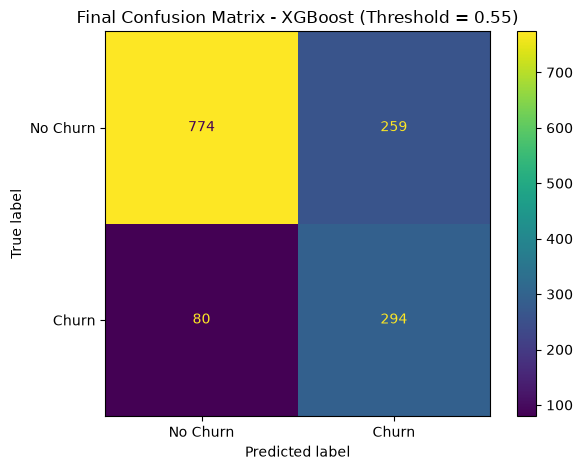

In [176]:
#Visualizing the confusion matrix for the final XGBoost model with the selected threshold
cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot()
plt.title('Final Confusion Matrix - XGBoost (Threshold = 0.55)')
plt.tight_layout()
plt.show()

* The model correctly identifies 774 customers as No Churn and 294 customers as Churn.

* The model incorrectly predicts 259 No Churn customers as Churn, resulting in false positives.

* Only 80 actual churn customers are incorrectly classified as No Churn, showing that the model captures most of the actual churn cases.

* The relatively high number of correctly identified churn customers (294) supports the use of the model for customer retention.

Overall, the confusion matrix shows that the selected threshold of 0.55 maintains good churn detection while keeping false negatives relatively low.


### Conclusion

This project developed an end-to-end customer churn prediction and deployment pipeline using machine learning. Multiple classification models were evaluated and tuned, with XGBoost selected based on its strong recall, F1-score, and ROC-AUC performance.

SHAP was used to explain the model predictions and identify the key factors influencing churn. Threshold optimization was also applied to improve churn detection beyond the default 0.5 classification threshold.

The final model is deployed as an application, allowing users to provide customer details and obtain a churn prediction based on the trained XGBoost model. This combines model development, evaluation, explainability, and deployment into a complete churn prediction workflow.


In [184]:
#Saving the final tuned XGBoost model to a file
tuned_xgb.save_model("final_xgb_churn_model.json")